# *SENTIMENT ANALYSIS FOR INDONESIAN POLTICIAL NEWS*
# this notebook using IndoBERT + BiLSTM model

versi: 2 juni 2026 - 20:44

# Import Library + define env & device

In [1]:
print("test")

test


In [2]:
import os
import random
import numpy as np
import pandas as pd
from collections import Counter
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_recall_fscore_support,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import MinMaxScaler

from transformers import (
    AutoTokenizer,
    AutoModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)
from transformers.modeling_outputs import SequenceClassifierOutput
import sys
import logging
import os
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


# ── File logger (tidak akan hilang meski layar disconnect) ──
log_path = "/kaggle/working/training_log.txt"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(message)s",
    handlers=[
        logging.FileHandler(log_path, mode="w", encoding="utf-8"),
        logging.StreamHandler(sys.stdout)  # tetap tampil di layar
    ]
)
log = logging.getLogger()

# Force flush setiap print
class FlushPrint:
    def write(self, msg):
        sys.__stdout__.write(msg)
        sys.__stdout__.flush()
    def flush(self):
        sys.__stdout__.flush()

sys.stdout = FlushPrint()
print(f"Log disimpan ke: {log_path}")

# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Imports complete. Running on: {device}")

# Configuration & Hyperparameter defining

In [3]:
# --- Configuration ---
SEED = 42
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 512

# Paths
DATA_PATH = "/kaggle/input/datasets/davinraffilio9/datalabeled"
MODEL_PATH = "/kaggle/working"

# Sentiment Model Hyperparameters
LSTM_HIDDEN = 256
LSTM_LAYERS = 2
DROPOUT = 0.2


set_seed(SEED)

print(f"Model: IndoBERT + BiLSTM ({LSTM_LAYERS} layers, {LSTM_HIDDEN} hidden)")
print(f"Max Length: {MAX_LENGTH}")

# Data loading & integration

In [4]:
# Load Data
df1 = pd.read_csv(f"{DATA_PATH}/cnbc_labeled.csv")
df2 = pd.read_csv(f"{DATA_PATH}/detik_labeled.csv")
df3 = pd.read_csv(f"{DATA_PATH}/kompas_labeled.csv")

print(f"Detik: {len(df1)} | CNBC: {len(df2)} | Kompas: {len(df3)}")

# Combine Datasets
required_cols = ["date", "title", "content", "article_id", "text", "label"]

def _select_cols(df: pd.DataFrame) -> pd.DataFrame:
    return df[required_cols].copy()

df_seed = pd.concat(
    [_select_cols(df1), _select_cols(df2), _select_cols(df3)],
    ignore_index=True
)

print(f"Total Combined Samples: {len(df_seed)}")

# EDA & data preprocessing

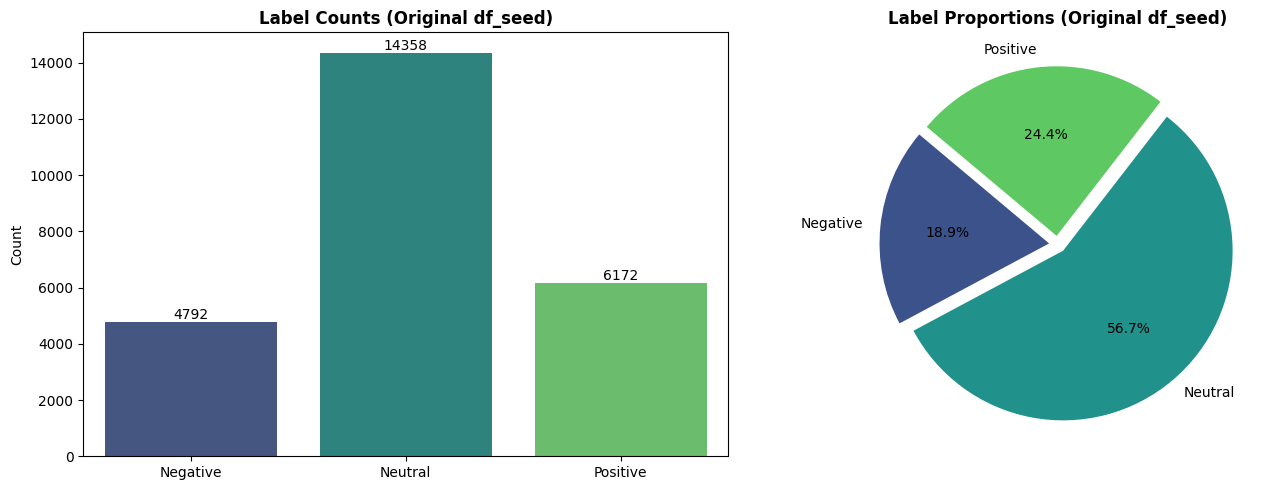

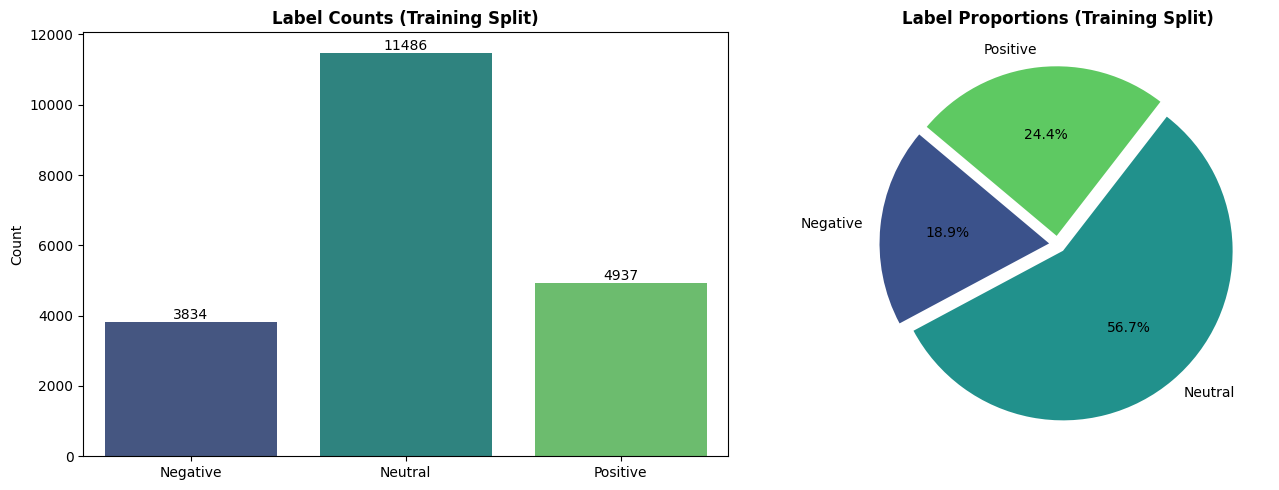

In [5]:

# --- 0. Setup Visualization Function ---
def plot_label_distribution(df, target_col='label', title_suffix=''):
    """
    Creates a bar plot and pie chart for label distribution.
    Auto-detects if labels are original (-1,0,1) or mapped (0,1,2).
    """
    viz_df = df.copy()
    
    # Auto-detect label format
    unique_labels = set(viz_df[target_col].unique())
    if unique_labels.issubset({0, 1, 2}):
        label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'} # Mapped ID
    else:
        label_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'} # Original Label
        
    viz_df['label_name'] = viz_df[target_col].map(label_map)
    order = ['Negative', 'Neutral', 'Positive']
    
    # Setup plot grid
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Bar Chart (Frequency)
    sns.countplot(x='label_name', data=viz_df, order=order, palette='viridis', ax=ax1)
    ax1.set_title(f'Label Counts {title_suffix}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylabel('Count')
    
    # Add numbers on top of bars
    for p in ax1.patches:
        ax1.annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black')

    # 2. Pie Chart (Proportion)
    counts = viz_df['label_name'].value_counts().reindex(order)
    ax2.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
            colors=sns.color_palette('viridis', 3), explode=(0.05, 0.05, 0.05))
    ax2.set_title(f'Label Proportions {title_suffix}', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# --- 1. Check & Visualize Distribution (Original Data) ---
print("="*50)
print("DATASET DISTRIBUTION (ORIGINAL)")
print("="*50)

# Text Output
print("Label Counts:")
print(df_seed['label'].map({-1:'Negative', 0:'Neutral', 1:'Positive'}).value_counts())

# Diagram Output
plot_label_distribution(df_seed, target_col='label', title_suffix='(Original df_seed)')


# --- 2. Train/Val Split ---
print("\n" + "="*50)
print("SPLITTING DATASET")
print("="*50)

train_df, val_df = train_test_split(
    df_seed,
    test_size=0.2,
    stratify=df_seed['label'],
    random_state=SEED
)

# Visualize Train Split to confirm Stratification
plot_label_distribution(train_df, target_col='label', title_suffix='(Training Split)')


# --- 3. Remap Labels (-1, 0, 1 -> 0, 1, 2) ---
label_to_id = {-1: 0, 0: 1, 1: 2}
id_to_label = {0: "negative", 1: "neutral", 2: "positive"}

train_df['label_id'] = train_df['label'].map(label_to_id)
val_df['label_id'] = val_df['label'].map(label_to_id)


# --- 4. Compute Class Weights ---
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['label_id']),
    y=train_df['label_id']
)

# Amplify minority class weights (Custom Adjustment)
# Logic: Give more focus to Negative/Positive, less to Neutral
class_weights = class_weights * np.array([1.5, 1.0, 1.5])
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("\n" + "="*50)
print("TRAINING CONFIGURATION")
print("="*50)
print(f"Train Size : {len(train_df)} samples")
print(f"Val Size   : {len(val_df)} samples")
print("-" * 30)
print("Computed Class Weights (for Loss Function):")
for i, label in enumerate(['Negative', 'Neutral', 'Positive']):
    print(f"  {label:<10}: {class_weights[i]:.4f}")

# Tokenization & dataset prep

In [6]:
# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding=False, # Padding handled by collator later
            return_tensors=None
        )
        
        return {
            'input_ids': encoding['input_ids'],
            'attention_mask': encoding['attention_mask'],
            'labels': label
        }

# Create Dataset Objects
train_dataset = SentimentDataset(train_df['text'].tolist(), train_df['label_id'].tolist(), tokenizer, MAX_LENGTH)
val_dataset = SentimentDataset(val_df['text'].tolist(), val_df['label_id'].tolist(), tokenizer, MAX_LENGTH)

print("✅ Dataset and Tokenizer ready.")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

# Model architecture definition (BiLSTM)

In [7]:
class IndoBertBiLSTM(nn.Module):
    def __init__(self, model_name, num_labels=3, lstm_hidden=256, lstm_layers=2, dropout=0.2, id_to_label=None, label_to_id=None):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.config = self.bert.config
        self.config.num_labels = num_labels
        
        if id_to_label:
            self.config.id2label = id_to_label
            self.config.label2id = label_to_id

        self.lstm = nn.LSTM(
            input_size=self.config.hidden_size,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden * 2, num_labels)
        self.num_labels = num_labels

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = bert_out.last_hidden_state

        # Pack sequence for LSTM
        lengths = attention_mask.sum(dim=1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        packed_out, (h_n, c_n) = self.lstm(packed)

        # Concat forward and backward hidden states
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        h = self.dropout(h)
        logits = self.classifier(h)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return SequenceClassifierOutput(loss=loss, logits=logits)

# Customize trainer & metrics

In [8]:
class FocalLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, focal_gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.focal_gamma = focal_gamma
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        ce_loss = F.cross_entropy(logits, labels, weight=self.class_weights, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
        
        return (focal_loss, outputs) if return_outputs else focal_loss

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    
    f1_per_class = f1_score(labels, preds, average=None)
    
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
        'f1_negative': f1_per_class[0],
        'f1_neutral': f1_per_class[1],
        'f1_positive': f1_per_class[2],
    }

# Training initialization

In [9]:
if not hasattr(sys.stdout, 'isatty'):
    sys.stdout.isatty = lambda: False

In [ ]:
# 1. Initialize Model
sentiment_model = IndoBertBiLSTM(
    model_name=MODEL_NAME,
    lstm_hidden=LSTM_HIDDEN,
    lstm_layers=LSTM_LAYERS,
    dropout=DROPOUT,
    id_to_label=id_to_label,
    label_to_id=label_to_id
).to(device)

# Training Arguments — PERSIS SAMA dengan GRU/CNN/FT
training_args = TrainingArguments(
    output_dir=f'{MODEL_PATH}/sentiment_training',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    save_total_limit=1,
    learning_rate=3e-5,
    num_train_epochs=15,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    lr_scheduler_type='cosine',
    warmup_ratio=0.1,
    logging_steps=50,
    report_to='none',
    fp16=True,
    dataloader_num_workers=2,
    seed=SEED,
)

trainer = FocalLossTrainer(
    class_weights=class_weights_tensor,
    focal_gamma=2.0,
    model=sentiment_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("✅ Trainer Initialized.")

# Execute training

In [11]:
print("="*40)
print("🚀 STARTING TRAINING")
print("="*40)

checkpoint_dir = f"{MODEL_PATH}/sentiment_training"
resume_from = None

if os.path.isdir(checkpoint_dir):
    checkpoints = [
        os.path.join(checkpoint_dir, d)
        for d in os.listdir(checkpoint_dir)
        if d.startswith("checkpoint-")
    ]
    if checkpoints:
        resume_from = max(checkpoints, key=os.path.getmtime)
        print(f"▶ Melanjutkan dari: {resume_from}")
    else:
        print("▶ Tidak ada checkpoint, mulai dari awal")
else:
    print("▶ Mulai training dari awal")

# Ganti trainer.train() lama dengan ini:
trainer.train(resume_from_checkpoint=resume_from)

print("✅ Training Complete.")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,F1 Negative,F1 Neutral,F1 Positive
1,0.679747,0.314776,0.535044,0.540265,0.482064,0.618781,0.373474,0.628540
2,0.528046,0.312679,0.590128,0.601376,0.558926,0.681102,0.483522,0.639504
3,0.386655,0.290702,0.619546,0.628312,0.598229,0.667426,0.541850,0.675660
4,0.322574,0.329332,0.593880,0.602550,0.562356,0.657914,0.487555,0.662181
5,0.216539,0.363648,0.657256,0.666268,0.647014,0.704952,0.613242,0.680610
6,0.164792,0.449844,0.753801,0.748726,0.755103,0.730681,0.765404,0.750092
7,0.119752,0.458765,0.731096,0.730541,0.731494,0.732369,0.733799,0.725456
8,0.077839,0.548264,0.763277,0.755601,0.764590,0.744186,0.781481,0.741136
9,0.039528,0.682565,0.763080,0.752612,0.764343,0.733886,0.785740,0.738211
10,0.042258,0.792728,0.773149,0.757596,0.773337,0.728238,0.801333,0.743217


# Final evaluation

In [12]:
print("Running Final Evaluation...")

# Predict
pred = trainer.predict(val_dataset)
y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=1)

# Metrics
final_metrics = trainer.evaluate()

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Accuracy    : {final_metrics['eval_accuracy']:.4f}")
print(f"Macro F1    : {final_metrics['eval_macro_f1']:.4f}")
print(f"Weighted F1 : {final_metrics['eval_weighted_f1']:.4f}")
print("-" * 50)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["negative", "neutral", "positive"], digits=4))

# analysis evaluation

In [13]:
!pip install PySastrawi

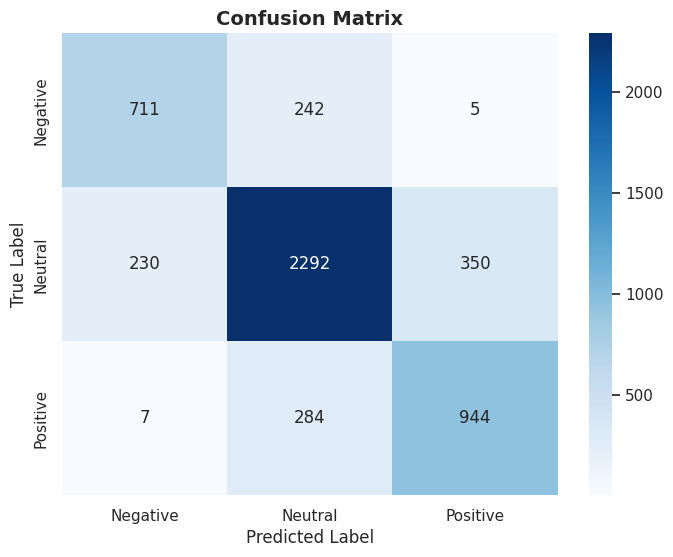

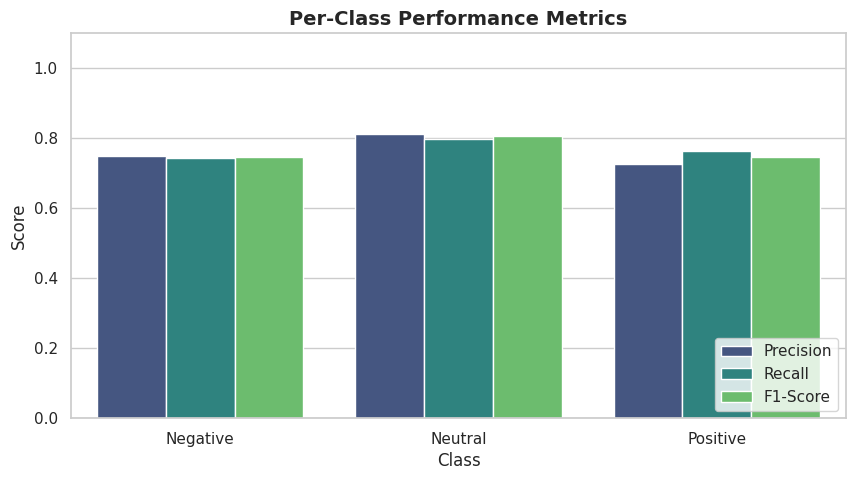

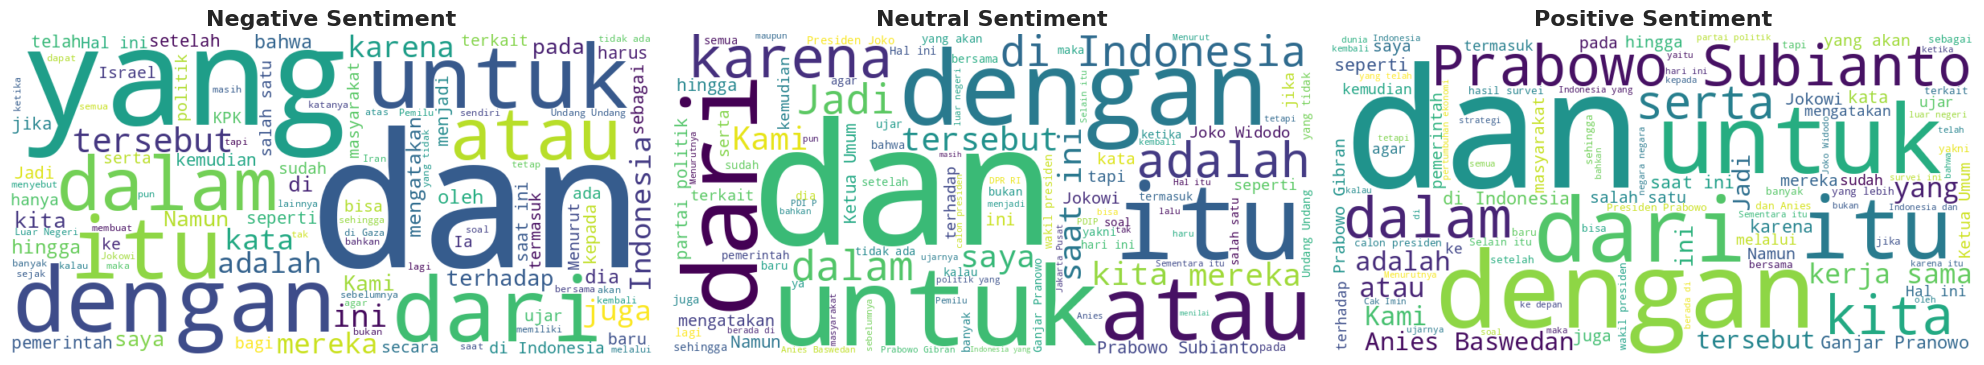

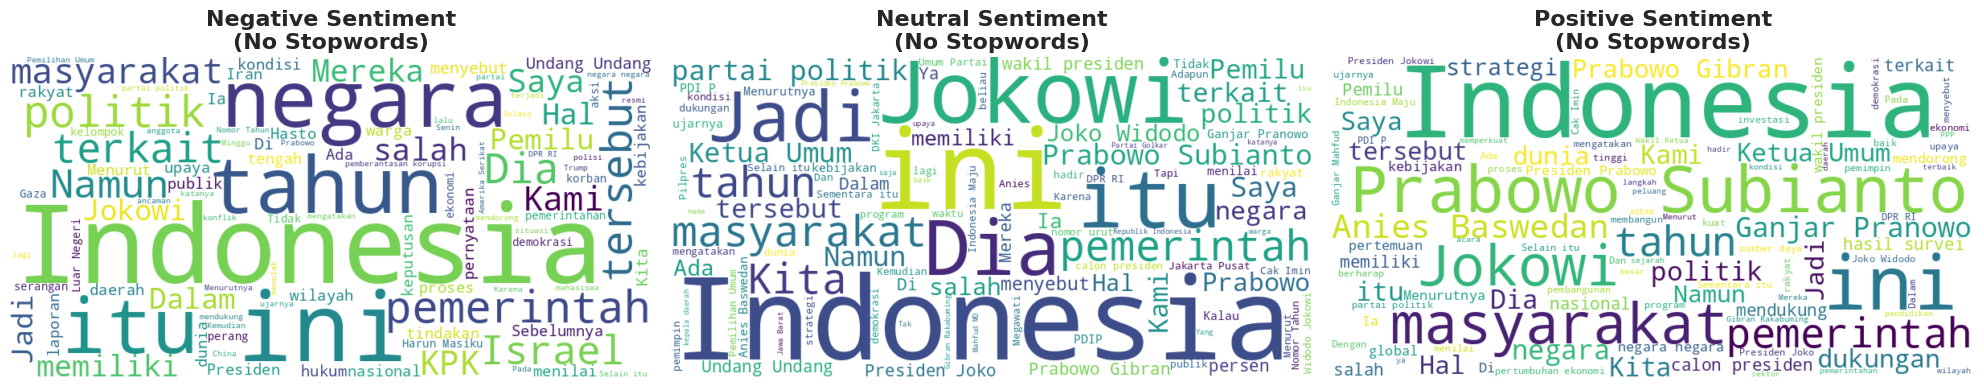

In [14]:
from wordcloud import WordCloud
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
# Pastikan style plot rapi
sns.set(style="whitegrid")

def plot_evaluation_results(y_true, y_pred, df_val):
    """
    Menampilkan Confusion Matrix, Grafik Metrik, dan Word Cloud.
    """
    target_names = ["Negative", "Neutral", "Positive"]
    
    # --- 1. Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.show()

    # --- 2. Per-Class Metrics Visualization (Precision, Recall, F1) ---
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
    
    metrics_df = pd.DataFrame({
        'Class': target_names * 3,
        'Score': np.concatenate([precision, recall, f1]),
        'Metric': ['Precision']*3 + ['Recall']*3 + ['F1-Score']*3
    })
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_df, palette='viridis')
    plt.title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(loc='lower right')
    plt.show()

    # --- 3. Word Clouds per Sentiment ---
    print("\n" + "="*50)
    print("MOST FREQUENT WORDS BY SENTIMENT")
    print("="*50)
    
    # Mapping label ID ke nama untuk filtering
    # Pastikan 'val_df' memiliki kolom 'text' dan 'label_id'
    # Kita menggunakan data validasi (df_val)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for i, label_name in enumerate(target_names):
        # Ambil teks dari data validasi yang label aslinya = i
        # Menggunakan kolom 'text' dari val_df
        subset_text = " ".join(df_val[df_val['label_id'] == i]['text'].astype(str).tolist())
        
        if not subset_text:
            subset_text = "No Data" # Handle jika kosong
            
        wc = WordCloud(width=800, height=400, background_color='white', 
                       colormap='viridis', max_words=100).generate(subset_text)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].axis('off')
        axes[i].set_title(f'{label_name} Sentiment', fontsize=16, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

    # --- 3. Word Clouds per Sentiment (With Sastrawi Stopword Removal) ---
    print("\n" + "="*50)
    print("MOST FREQUENT WORDS BY SENTIMENT (CLEANED)")
    print("="*50)
    
    # 1. Inisialisasi Sastrawi StopWord Remover
    factory = StopWordRemoverFactory()
    stopword_remover = factory.create_stop_word_remover()
    
    # Mapping target_names jika belum didefinisikan di luar fungsi
    target_names = ["Negative", "Neutral", "Positive"]
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for i, label_name in enumerate(target_names):
        # Ambil teks dari data validasi yang label aslinya = i (0, 1, 2)
        # Menggunakan kolom 'text' dari df_val sesuai struktur dataset kita
        raw_subset_text = " ".join(df_val[df_val['label_id'] == i]['text'].astype(str).tolist())
        
        if raw_subset_text:
            # 2. Terapkan Stopword Removal dari Sastrawi
            # Proses ini akan menghilangkan kata umum bahasa Indonesia
            cleaned_text = stopword_remover.remove(raw_subset_text)
        else:
            cleaned_text = "No Data"
            
        # 3. Generate WordCloud dari teks yang sudah bersih
        wc = WordCloud(
            width=800, 
            height=400, 
            background_color='white', 
            colormap='viridis', 
            max_words=100
        ).generate(cleaned_text)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].axis('off')
        axes[i].set_title(f'{label_name} Sentiment\n(No Stopwords)', fontsize=16, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# --- EKSEKUSI VISUALISASI ---
# Pastikan val_df tersedia dari cell sebelumnya
plot_evaluation_results(y_true, y_pred, val_df)

# save model

In [15]:
import os
import torch
import json

# Tentukan direktori penyimpanan
SAVE_DIR = f"{MODEL_PATH}/final_indobert_bilstm_model"
os.makedirs(SAVE_DIR, exist_ok=True)

print("="*50)
print("💾 SAVING FINAL MODEL & TOKENIZER")
print("="*50)

# 1. Simpan bobot model custom (State Dict PyTorch)
model_save_path = os.path.join(SAVE_DIR, "pytorch_model.bin")
torch.save(sentiment_model.state_dict(), model_save_path)
print(f"✔️ Model weights saved to: {model_save_path}")

# 2. Simpan Tokenizer (Bawaan Hugging Face)
tokenizer.save_pretrained(SAVE_DIR)
print(f"✔️ Tokenizer saved to: {SAVE_DIR}")

# 3. Simpan Config & Label Mapping (Buat mempermudah inference)
label_mapping = {
    "id2label": id_to_label,
    "label2id": label_to_id,
    "max_length": MAX_LENGTH,
    "lstm_hidden": LSTM_HIDDEN,
    "lstm_layers": LSTM_LAYERS,
    "dropout": DROPOUT
}

with open(os.path.join(SAVE_DIR, "model_config.json"), "w") as f:
    json.dump(label_mapping, f, indent=4)
print(f"✔️ Model config & label mapping saved to: {os.path.join(SAVE_DIR, 'model_config.json')}")

print("\n✅ Proses save model selesai!")

In [16]:
import shutil

shutil.make_archive('/kaggle/working/model_indobert_bilstm_siap_download', 'zip', '/kaggle/working/final_indobert_bilstm_model')

print("Berhasil di-zip! Silakan refresh panel Output dan download file .zip-nya.")

# Ablation Study (R10 - Reviewer Response)
## Comparing CLS vs Mean Pooling + Hidden Size Variants

In [ ]:
# ⏭️ ABLATION 1 (CLS vs Mean Pooling) — TEMPORARILY DISABLED
# re-enable after model save confirmed
# Fix needed when re-enabling: change tokenizer=tokenizer → processing_class=tokenizer
#
# class IndoBertBiLSTM_Ablation(nn.Module): ...
# def quick_train_eval(pooling_strategy, epochs=5, lr=3e-5): ...
# res_cls, rep_cls = quick_train_eval('cls')
# res_mean, rep_mean = quick_train_eval('mean')

print("⏭️ Ablation 1 (Pooling Strategy) skipped")

## Ablation Study 2: Focal Loss Gamma Variants (R10)

In [ ]:
# ⏭️ ABLATION 2 (Focal Loss Gamma) — TEMPORARILY DISABLED
# re-enable after model save confirmed
# Fix needed: tokenizer=tokenizer → processing_class=tokenizer

print("⏭️ Ablation 2 (Focal Loss Gamma) skipped")

## Ablation Study 3: BiLSTM Hidden Size (R10)

In [ ]:
# ⏭️ ABLATION 3 (BiLSTM Hidden Size) — TEMPORARILY DISABLED
# re-enable after model save confirmed
# Fix needed: tokenizer=tokenizer → processing_class=tokenizer

print("⏭️ Ablation 3 (Hidden Size) skipped")

# K-Fold Cross-Validation (R2, R8 - Reviewer Response)
## Membuktikan stabilitas hasil bukan artefak satu split

In [ ]:
# ⏭️ K-FOLD CV — TEMPORARILY DISABLED
# re-enable after model save confirmed
# Bugs fixed: double comma gradient_accumulation_steps=2,,
#             tokenizer=tokenizer → processing_class=tokenizer

print("⏭️ K-Fold CV skipped")

# Explainable AI - SHAP Analysis (R8 - Reviewer Response)
## Interpretability: fitur mana yang paling mempengaruhi prediksi

In [ ]:
# ⏭️ XAI (Integrated Gradients) — TEMPORARILY DISABLED
# re-enable after model save confirmed

print("⏭️ XAI (Integrated Gradients) skipped")

# Computational Efficiency Analysis (R8 - Reviewer Response)
## Mengukur inference time dan memory footprint

In [ ]:
# ⏭️ STATISTICAL SIGNIFICANCE — TEMPORARILY DISABLED
# re-enable after model save confirmed

print("⏭️ Statistical Significance skipped")

# Save Final Predictions (untuk cross-model significance test)

In [ ]:
# ================================================================
# Simpan prediksi final BiLSTM untuk dipakai di McNemar's test
# ketika membandingkan dengan model lain (GRU, CNN, dll)
# ================================================================
import numpy as np

np.save(f"{MODEL_PATH}/bilstm_val_preds.npy", y_pred)
np.save(f"{MODEL_PATH}/bilstm_val_true.npy",  y_true)

print(f"✅ BiLSTM predictions saved:")
print(f"   {MODEL_PATH}/bilstm_val_preds.npy  -> shape {y_pred.shape}")
print(f"   {MODEL_PATH}/bilstm_val_true.npy   -> shape {y_true.shape}")
print()
print("Gunakan file ini di notebook GRU/CNN untuk McNemar's test.")
